# 4. RL Training

Train the RL agent using Maskable PPO.

## 4.0 Install Dependencies

In [1]:
# Install required packages (safe to re-run; --quiet suppresses noise)
import subprocess, sys
subprocess.check_call([sys.executable, '-m', 'pip', 'install', '--quiet',
    'numpy',
    'pandas',
    'joblib',
    'gymnasium',
    'stable-baselines3',
    'sb3-contrib',
    'tqdm',
    'rich',
    'sentence-transformers',
])
# Install CPU-only torch (use the CUDA index URL if you have a GPU):
# GPU:  --index-url https://download.pytorch.org/whl/cu121
subprocess.check_call([sys.executable, '-m', 'pip', 'install', '--quiet',
    'torch', '--index-url', 'https://download.pytorch.org/whl/cpu',
])


[notice] A new release of pip is available: 25.1.1 -> 26.2.1
[notice] To update, run: /mnt/hdd/Code/Git/bwa/.venv/bin/python -m pip install --upgrade pip



[notice] A new release of pip is available: 25.1.1 -> 26.2.1
[notice] To update, run: /mnt/hdd/Code/Git/bwa/.venv/bin/python -m pip install --upgrade pip


0

## 4.1 Setup

In [2]:
# ── Google Colab / Google Drive setup ────────────────────────────────────────
# When running on Colab, mount your Drive and set DRIVE_REPO_PATH to the folder
# where you cloned / uploaded this repo (e.g. '/content/drive/MyDrive/bwa').
# Leave DRIVE_REPO_PATH as None when running locally — it will be ignored.
import os, sys
from pathlib import Path

DRIVE_REPO_PATH = '/content/drive/MyDrive/bwa'   # ← change to your Drive path when on Colab
                         #   e.g. '/content/drive/MyDrive/bwa'

ON_COLAB = 'google.colab' in sys.modules or os.path.exists('/content')

if ON_COLAB and DRIVE_REPO_PATH is not None:
    from google.colab import drive
    drive.mount('/content/drive', force_remount=False)
    REPO_ROOT = Path(DRIVE_REPO_PATH)
    print(f'Colab + Drive: repo root → {REPO_ROOT}')
else:
    # Local: walk up from cwd until we find src/data_ingestion.py
    REPO_ROOT = None
    for _p in [Path.cwd(), *Path.cwd().parents]:
        if (_p / 'src' / 'data_ingestion.py').exists():
            REPO_ROOT = _p
            break
    if REPO_ROOT is None:
        raise RuntimeError('Could not locate repo root. Set DRIVE_REPO_PATH or run from inside the repo.')
    print(f'Local: repo root → {REPO_ROOT}')

_src = str(REPO_ROOT / 'src')
if _src not in sys.path:
    sys.path.insert(0, _src)

DATASET = "BPIC2012"
OUTPUT_DIR = REPO_ROOT / 'output' / DATASET
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
print(f'OUTPUT_DIR → {OUTPUT_DIR}')

Local: repo root → /mnt/hdd/Code/Git/bwa
OUTPUT_DIR → /mnt/hdd/Code/Git/bwa/output/BPIC2012


## 4.1 Load Twin & Embeddings

In [3]:
import joblib
twin = joblib.load(OUTPUT_DIR / f'digital_twin_{DATASET}_train.pkl')
embedder = joblib.load(OUTPUT_DIR / f'activity_embeddings.model')
print(f"Loaded twin: {len(twin.activities)} activities")

Loaded twin: 24 activities


## 4.2 Setup Env

In [4]:
from env_factory import build_process_env
from kpi_actions import MANAGEMENT_ACTIONS, N_MANAGEMENT_ACTIONS, RULE_DESCRIPTIONS
from reward_config import DEFAULT as DEFAULT_REWARD

# Write the intended reward BEFORE building the environment.
#
# build_process_env prefers reward_config.json on disk, so that notebooks 05
# and 06 grade the agent with exactly what training used. The consequence is
# that the file has to be current before the env is built — otherwise a config
# left behind by an earlier run silently wins, and changing the default in code
# has no effect. That is what tripped the assertion at the end of the reward
# cell below.
DEFAULT_REWARD.save(OUTPUT_DIR)

# One factory builds the environment for training (here), evaluation
# (notebook 05) and analysis (notebook 06). These three notebooks used to
# construct ProcessEnv by hand, and drifted: only this one applied the tuned
# reward weights, so the agent was graded under a reward it never trained on.
# See src/env_factory.py and src/reward_config.py.
env, env_meta = build_process_env(OUTPUT_DIR)

twin           = env.twin
embedder       = env.embed_model
_n_activities  = env_meta['n_activities']
_median_len    = env_meta['median_trace_length']
_embed_dim     = env_meta['embed_dim']
_max_steps     = env_meta['max_steps']

print(f'Environment for {env_meta["dataset"]}')
print(f'  activities   = {_n_activities}  →  embed_dim = {_embed_dim}')
print(f'  median trace = {_median_len:.0f}  →  max_steps = {_max_steps}')
print(f'  good terminals: {env_meta["good_terminals"]}')
print(f'  bad terminals:  {env_meta["bad_terminals"]}')
print()
print('Reward config — identical in notebooks 04, 05 and 06, and across datasets:')
for k, v in env_meta['reward_config'].items():
    if v is not None:
        print(f'  {k:<16s} = {v}')
print()
print('Per-step weights for this trace length (share x w_terminal / median trace):')
for k, v in env_meta['resolved_per_step_weights'].items():
    print(f'  {k:<16s} = {v:.4f}')

print()
print(f'Action space: {env.action_space}')
print(f'  Routing actions  (dim 0): {env._max_succ}  — one slot per possible next activity')
print(f'  Management actions (dim 1): {N_MANAGEMENT_ACTIONS}  — KPI-based interventions')
print(f'Observation keys: {list(env.observation_space.spaces.keys())}')
print()
print('Management actions available:')
for a in MANAGEMENT_ACTIONS:
    print(f'  [{a.index:2d}] {a.name:<40s}  {a.description}')

Environment for BPIC2012
  activities   = 24  →  embed_dim = 32
  median trace = 11  →  max_steps = 150
  good terminals: ['A_ACTIVATED', 'A_APPROVED', 'A_REGISTERED', 'O_ACCEPTED']
  bad terminals:  ['A_CANCELLED', 'A_DECLINED', 'O_DECLINED']

Reward config — identical in notebooks 04, 05 and 06, and across datasets:
  w_terminal       = 30.0
  w_bad_terminal   = -30.0
  w_length_bonus   = 5.0
  progress_share   = 0.0
  step_share       = 0.02
  w_loop           = 1.0
  time_share       = 0.25
  time_penalty_mode = two_sided
  time_penalty_cap = 6.0
  intervention_cost_share = 1.0
  effect_scale     = 1.0

Per-step weights for this trace length (share x w_terminal / median trace):
  w_progress       = 0.0000
  w_step           = 0.0545

Action space: MultiDiscrete([14 15])
  Routing actions  (dim 0): 14  — one slot per possible next activity
  Management actions (dim 1): 15  — KPI-based interventions
Observation keys: ['case_embedding', 'kpi_signals', 'mgmt_action_mask', 'resource_sta

## 4.3 Reward Weight Tuning

Searches for reward weights that produce KPI outcomes matching the real log.
Runs ~60 short rollouts under a random policy and scores each weight vector
by how closely the achieved completion rate and rework match the real log targets.

C2 env weight mapping:
- `w_completion` → `w_terminal` (bonus for reaching terminal activity)
- `w_rework`     → `w_loop`     (penalty per excess routing loop)
- `w_delay`      → `w_progress` (bonus for moving toward terminal)
- `w_throughput` → `w_step`     (per-step cost to incentivise efficiency)

Takes ~2–3 minutes. Skip and re-run training if you want to use the defaults.

In [5]:
from reward_config import RewardConfig, DEFAULT as DEFAULT_REWARD

# The reward is fixed and shared across all three datasets. It is NOT tuned
# per dataset any more.
#
# Why this changed. The random search in reward_tuning.py returned a different
# weight vector for each dataset — the per-step cost came out as 0.05, 0.2 and
# 0.02 on BPIC2012 / BPIC2015 / BPIC2017. Those weights were then applied here
# and nowhere else, so evaluation ran with w_terminal = 0 while training ran
# with w_terminal = 30. That single difference is the whole gap between the
# training plateau (~+36) and the reported evaluation means (+6.59 and friends).
#
# Using one shared reward removes the gap and makes the paper's "no per-dataset
# tuning" claim true as written. The tuned weights are still on disk, and the
# old behaviour can be reproduced for comparison:
#
#     legacy = RewardConfig.from_legacy_file(OUTPUT_DIR / 'reward_weights.json')
#     env, env_meta = build_process_env(OUTPUT_DIR, reward_config=legacy)
#
# Nothing does that by default.

reward_path = DEFAULT_REWARD.save(OUTPUT_DIR)

print('Reward config in use (shared across datasets):')
for k, v in DEFAULT_REWARD.to_dict().items():
    print(f'  {k:<16s} = {v}')
print()
print(f'Saved to {reward_path}')

legacy_path = OUTPUT_DIR / 'reward_weights.json'
if legacy_path.exists():
    legacy = RewardConfig.from_legacy_file(legacy_path)
    diff = DEFAULT_REWARD.differences(legacy)
    if diff:
        print()
        print('For reference, this dataset\'s old tuned weights differed in:')
        for key, (now, before) in diff.items():
            print(f'  {key:<16s} now {now}   previously {before}')

assert env.reward_config == DEFAULT_REWARD, (
    'Environment reward does not match the shared config — rebuild the env.'
)

Reward config in use (shared across datasets):
  w_terminal       = 30.0
  w_bad_terminal   = -30.0
  w_length_bonus   = 5.0
  progress_share   = 0.0
  step_share       = 0.02
  w_loop           = 1.0
  time_share       = 0.25
  time_penalty_mode = two_sided
  time_penalty_cap = 6.0
  intervention_cost_share = 1.0
  effect_scale     = 1.0
  w_progress_abs   = None
  w_step_abs       = None

Saved to /mnt/hdd/Code/Git/bwa/output/BPIC2012/reward_config.json

For reference, this dataset's old tuned weights differed in:
  w_loop           now 1.0   previously 2.0
  w_progress_abs   now None   previously 0.3
  w_step_abs       now None   previously 0.05


## 4.4 Train

In [6]:
# Force unbuffered stdout so log lines appear live in Jupyter
import os
os.environ['PYTHONUNBUFFERED'] = '1'

from env_factory import save_run_config
from experiment import train_policy, EARLY_STOPPING, LOG_INTERVAL, MAX_STEPS

SEED = 0        # training seed — vary this to measure run-to-run spread

# The training setup itself lives in src/experiment.py, not in this cell.
#
# run_experiments.py has to train dozens of policies — five seeds for the
# across-seed spread (A4), and a sweep over the assumed intervention effect
# sizes — and a script that re-implements what this cell does is exactly the
# drift Fix 3 was about: notebook 04 applied the tuned reward, notebooks 05
# and 06 did not, and the agent was graded under a reward it never trained on.
#
# So there is one train_policy() and this notebook calls it. Changing a
# hyperparameter changes it for the sweep too, which is the point. Everything
# except the seed is an SB3 default, and early stopping is fixed for every
# dataset — it used to scale with w_terminal and the activity count, which
# contradicted the claim that identical hyperparameters are used throughout.

print(f'Early stopping: '
      + '  '.join(f'{k}={v}' for k, v in EARLY_STOPPING.items())
      + '  (same for all datasets)')
print(f'Training up to {MAX_STEPS:,} steps, seed={SEED} (early stopping enabled)...')
print(f'Action space: {env.action_space}  (routing + management)')

model, run_info = train_policy(
    env,
    seed=SEED,
    log_path=OUTPUT_DIR / 'rl_model',
    max_steps=MAX_STEPS,
    log_interval=LOG_INTERVAL,
    verbose=1,
)

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
model.save(OUTPUT_DIR / 'rl_model/best_model.zip')
print('Model saved')

# Record everything needed to reproduce this run, next to its outputs.
# run_info carries the seed, the step count actually run, the early-stopping
# settings and every PPO hyperparameter, so the record cannot disagree with
# what was run.
config_path = save_run_config(OUTPUT_DIR, env_meta, **run_info)
print(f'Run configuration written to {config_path}')


Early stopping: window=5  min_delta=0.3  patience=8  (same for all datasets)
Training up to 500,000 steps, seed=0 (early stopping enabled)...
Action space: MultiDiscrete([14 15])  (routing + management)


───────────────────────────────────────────────────────────────────────────────────


    step    eps       rew       ±   term   good    bad   trnc      H      ev    fps


───────────────────────────────────────────────────────────────────────────────────


   10000    540     +1.15   14.91  100%   17%   83%    0%   2.35   0.239    707


...

  310000  23898    +15.00   13.45  100%   18%   82%    0%   1.56   0.030    471


  [EarlyStopping] step=310000  smoothed=+15.24  best=+15.32  Δ=-0.081  patience=7/8


  320000  24747    +14.99   12.83  100%   15%   85%    0%   1.57   0.016    498


  [EarlyStopping] step=320000  smoothed=+15.19  best=+15.32  Δ=-0.131  patience=8/8
  [EarlyStopping] Stopping at step 320000 — smoothed reward plateaued at +15.19 for 8 consecutive checks.
───────────────────────────────────────────────────────────────────────────────────


Model saved
Run configuration written to /mnt/hdd/Code/Git/bwa/output/BPIC2012/config_used.json


## 4.4 Training Visualization

Final: reward +14.99  episode length 11.8 (real median 9)  good outcomes 14.6% (real base rate 17.7%)
Saved to /mnt/hdd/Code/Git/bwa/output/BPIC2012/training_progress.png


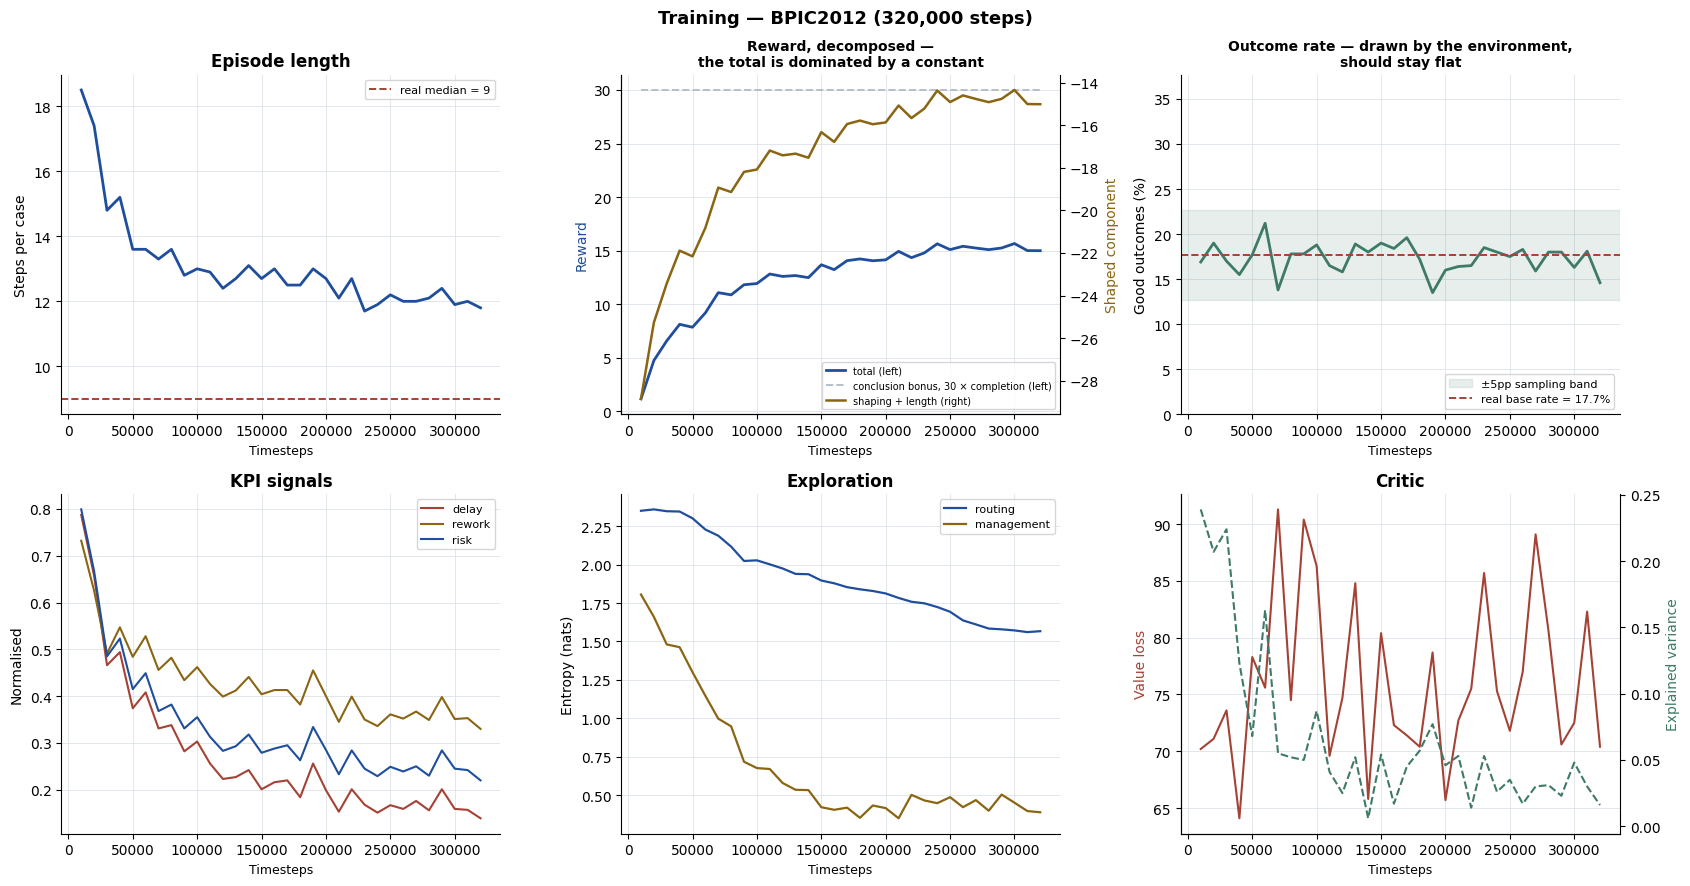

In [7]:
import figures, json
import pandas as pd

metrics_file = OUTPUT_DIR / 'rl_model' / 'training_metrics.csv'

if not metrics_file.exists():
    print('No training data yet - run the Train cell first.')
else:
    _metrics = pd.read_csv(metrics_file)
    _tc = json.load(open(OUTPUT_DIR / 'terminal_classification.json'))

    # Rebuilt around what actually moves.
    #
    # Removed: the completion-rate panel, which ran 1.000..1.000 across the
    # whole of BPIC2012's training, and one of action_entropy / routing_entropy
    # (byte-identical on all three datasets).
    #
    # Promoted: episode length, which is the learning curve now - 17.2 down to
    # 9.3 on BPIC2012 while total reward moved only 33.35..34.25.
    #
    # Added: a reward decomposition, because the total is dominated by the
    # fixed conclusion bonus and reads as "nothing was learned" otherwise; and
    # the outcome rate, labelled as a line that should NOT move, since drift
    # there would mean the verdict is leaking back to the agent.
    figures.training_progress(
        _metrics,
        out_path=OUTPUT_DIR / 'training_progress.png',
        dataset=DATASET,
        real_steps_median=_tc['steps_to_outcome']['p50'],
        base_rate=_tc['outcome_base_rates']['p_good'],
        w_terminal=env.reward_config.w_terminal,
    )
    _last = _metrics.iloc[-1]
    print(f"Final: reward {_last.ep_reward_mean:+.2f}  "
          f"episode length {_last.ep_len_mean:.1f} "
          f"(real median {_tc['steps_to_outcome']['p50']:.0f})  "
          f"good outcomes {_last.good_terminal_rate:.1%} "
          f"(real base rate {_tc['outcome_base_rates']['p_good']:.1%})")
    print(f'Saved to {OUTPUT_DIR / "training_progress.png"}')
